In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#creating path for data import 
path = r'/Users/thomaskimber/Desktop/Task 7'

In [3]:
# importing UFC data csv 
df = pd.read_csv(os.path.join(path, 'ufc_data.csv' ), index_col = False)

In [4]:
df.shape

(6012, 144)

Below, I am going to look at whether the age of the fighter can be a predictor of the length of the fight. My hypothesis is that as a fighter gets older and gets more experience, they are able to last longer in the ring. However, this can also go against us, since more experience might also mean they are able to finish fights quicker.  

   avg_age  avg_fight_time
0     29.0      348.750000
1     30.0      662.421875
4     36.0      819.190430
5     34.0      683.589844
6     33.0      627.265625


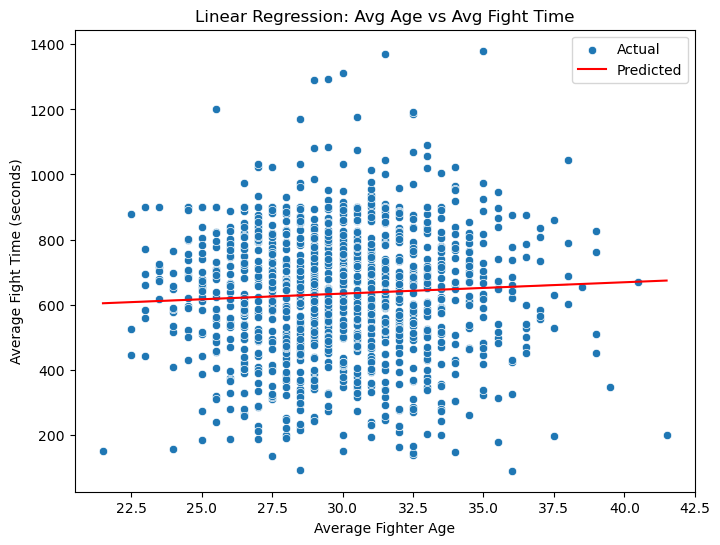

Mean Squared Error: 38008.438756076626
R2 Score: -0.0027934361215853354
          Actual   Predicted
5168  652.500000  632.105811
1676  709.182617  618.145196
4967  508.437500  626.870580
4352  523.000000  614.655042
3319  601.750000  642.576272


In [6]:
# ============================
# 1. Data Cleaning
# ============================

# Create average fighter age
df['avg_age'] = (df['B_age'] + df['R_age']) / 2

# Create average fight time (seconds)
df['avg_fight_time'] = (df['B_total_time_fought(seconds)'] + df['R_total_time_fought(seconds)']) / 2

# Keep only relevant columns and drop missing values
df_reg = df[['avg_age', 'avg_fight_time']].dropna()

# Quick check
print(df_reg.head())


# ============================
# 2. Define X and y
# ============================

X = df_reg[['avg_age']]  # independent variable
y = df_reg['avg_fight_time']  # dependent variable


# ============================
# 3. Split into train/test
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ============================
# 4. Train the Model
# ============================

model = LinearRegression()
model.fit(X_train, y_train)


# ============================
# 5. Predictions
# ============================

y_pred = model.predict(X_test)


# ============================
# 6. Visualization
# ============================

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_test['avg_age'], y=y_test, label="Actual")
sns.lineplot(x=X_test['avg_age'], y=y_pred, color="red", label="Predicted")
plt.xlabel("Average Fighter Age")
plt.ylabel("Average Fight Time (seconds)")
plt.title("Linear Regression: Avg Age vs Avg Fight Time")
plt.legend()
plt.show()


# ============================
# 7. Model Performance
# ============================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


# ============================
# 8. Compare predictions with actuals
# ============================

results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(results.head())

From above, we can see there is a relationship between the age of a fighter and the length of the fight; this is a bad predictor to estimate the length of a fight. Next, I wanted to see if weight could be a predictor of the length of the fight, with the hypothesis being that the bigger they are, the less likely the fight will go longer since they are more powerful and more likely to be less fit than smaller fighters. 

   avg_weight_lbs  avg_fight_time_min
0           135.0            5.812500
1           195.0           11.040365
4           135.0           13.653174
5           150.0           11.393164
6           170.0           10.454427
Regression Slope: -0.0265
Regression Intercept: 15.0254


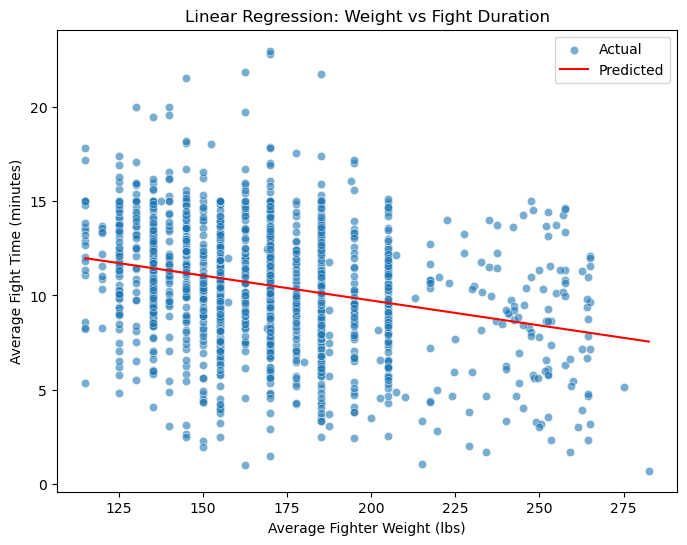

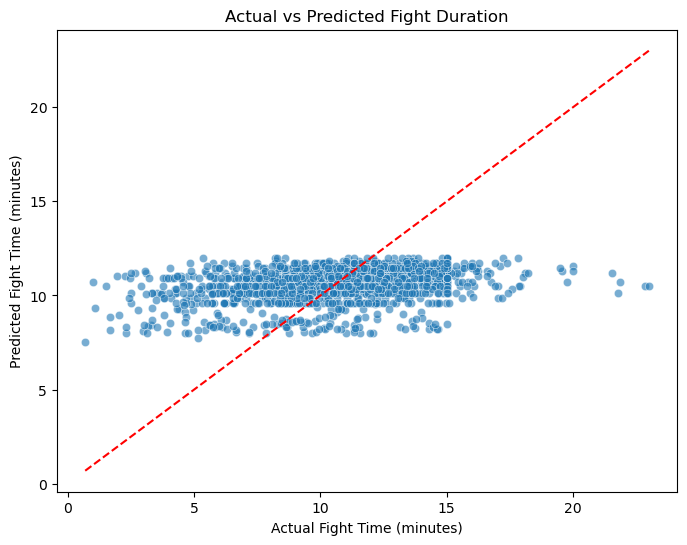

Mean Squared Error: 10.236320567975396
R2 Score: 0.08794967134265119
      Actual (min)  Predicted (min)
5838      8.620833         8.751863
2590     10.995703         8.023927
2476      9.940625        10.922437
3273      7.391667        10.326853
4349      7.683984        10.128325
Correlation between Weight and Fight Duration: -0.2910168273809436


In [7]:
# ============================
# 1. Data Cleaning
# ============================

# Average fighter weight
df['avg_weight_lbs'] = (df['B_Weight_lbs'] + df['R_Weight_lbs']) / 2

# Average fight time (convert to minutes)
df['avg_fight_time_min'] = (df['B_total_time_fought(seconds)'] + df['R_total_time_fought(seconds)']) / 120  

# Keep relevant columns and drop NAs
df_weight = df[['avg_weight_lbs', 'avg_fight_time_min']].dropna()

print(df_weight.head())


# ============================
# 2. Define X and y
# ============================

X = df_weight[['avg_weight_lbs']]  # independent variable
y = df_weight['avg_fight_time_min']  # dependent variable


# ============================
# 3. Train/Test Split
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ============================
# 4. Train Linear Regression
# ============================

model = LinearRegression()
model.fit(X_train, y_train)


# ============================
# 5. Model Coefficients
# ============================

slope = model.coef_[0]
intercept = model.intercept_

print(f"Regression Slope: {slope:.4f}")
print(f"Regression Intercept: {intercept:.4f}")


# ============================
# 6. Predictions
# ============================

y_pred = model.predict(X_test)


# ============================
# 7. Visualization
# ============================

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_test['avg_weight_lbs'], y=y_test, label="Actual", alpha=0.6)
sns.lineplot(x=X_test['avg_weight_lbs'], y=y_pred, color="red", label="Predicted")
plt.xlabel("Average Fighter Weight (lbs)")
plt.ylabel("Average Fight Time (minutes)")
plt.title("Linear Regression: Weight vs Fight Duration")
plt.legend()
plt.show()

# Plot Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Fight Time (minutes)")
plt.ylabel("Predicted Fight Time (minutes)")
plt.title("Actual vs Predicted Fight Duration")
plt.show()


# ============================
# 8. Model Performance
# ============================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


# ============================
# 9. Compare predictions with actuals
# ============================

results = pd.DataFrame({"Actual (min)": y_test, "Predicted (min)": y_pred})
print(results.head())


# ============================
# 10. Correlation Check
# ============================

correlation = df_weight['avg_weight_lbs'].corr(df_weight['avg_fight_time_min'])
print("Correlation between Weight and Fight Duration:", correlation)


as we can see there is no correlation between these two varibles and weight is not a good variable to predict the length of a fight

Next, I looked at the age gap to see if it affected the length of the fight. The hypothesis was that the larger the age gap, the shorter the fight. 

   age_gap  avg_fight_time_sec
0      4.0          348.750000
1      4.0          662.421875
4     14.0          819.190430
5     14.0          683.589844
6      4.0          627.265625
Regression Slope: -0.8790 sec per year of age gap
Regression Intercept: 637.4536 sec


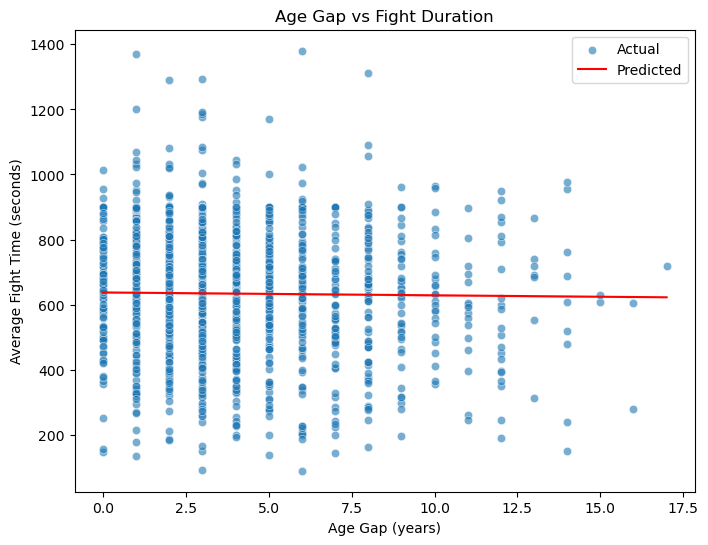

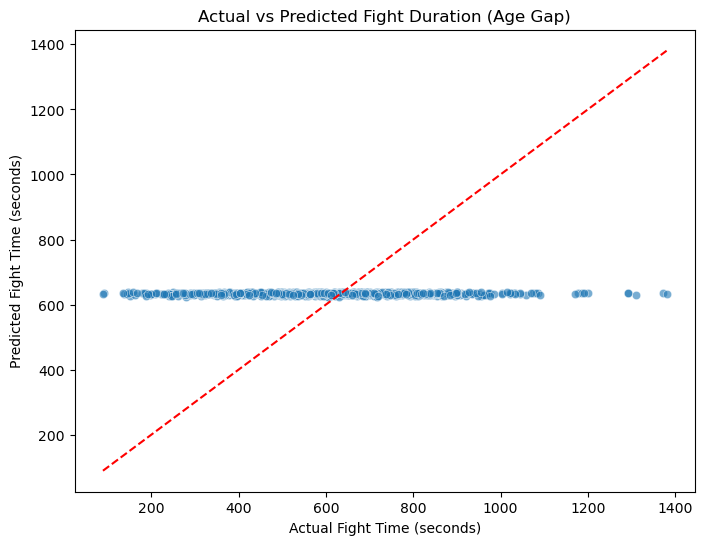

Mean Squared Error: 37826.88807030671
R2 Score: 0.001996495850675517
Correlation between Age Gap and Fight Duration: -0.03604946606954444


In [9]:
# ============================
# 1. Feature Engineering
# ============================

# Calculate absolute age gap between fighters
df['age_gap'] = abs(df['B_age'] - df['R_age'])

# Average fight time (seconds)
df['avg_fight_time_sec'] = (df['B_total_time_fought(seconds)'] + df['R_total_time_fought(seconds)']) / 2  

# Keep relevant columns and drop missing values
df_age = df[['age_gap', 'avg_fight_time_sec']].dropna()

print(df_age.head())


# ============================
# 2. Define X and y
# ============================

X = df_age[['age_gap']]  # independent variable
y = df_age['avg_fight_time_sec']  # dependent variable


# ============================
# 3. Train/Test Split
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ============================
# 4. Train Linear Regression
# ============================

model = LinearRegression()
model.fit(X_train, y_train)


# ============================
# 5. Model Coefficients
# ============================

slope = model.coef_[0]
intercept = model.intercept_

print(f"Regression Slope: {slope:.4f} sec per year of age gap")
print(f"Regression Intercept: {intercept:.4f} sec")


# ============================
# 6. Predictions
# ============================

y_pred = model.predict(X_test)


# ============================
# 7. Visualization
# ============================

# Scatterplot with regression line
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_test['age_gap'], y=y_test, label="Actual", alpha=0.6)
sns.lineplot(x=X_test['age_gap'], y=y_pred, color="red", label="Predicted")
plt.xlabel("Age Gap (years)")
plt.ylabel("Average Fight Time (seconds)")
plt.title("Age Gap vs Fight Duration")
plt.legend()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Fight Time (seconds)")
plt.ylabel("Predicted Fight Time (seconds)")
plt.title("Actual vs Predicted Fight Duration (Age Gap)")
plt.show()


# ============================
# 8. Model Performance
# ============================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


# ============================
# 9. Correlation Check
# ============================

correlation = df_age['age_gap'].corr(df_age['avg_fight_time_sec'])
print("Correlation between Age Gap and Fight Duration:", correlation)


once again this is not a good model to predict the length of the fight 